Loading required package: ggplot2

Loading required package: lattice


Attaching package: ‘caret’


The following object is masked from ‘package:tensorflow’:

    train


The following object is masked from ‘package:httr’:

    progress



Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union



Attaching package: ‘gridExtra’


The following object is masked from ‘package:dplyr’:

    combine


Type 'citation("pROC")' for a citation.


Attaching package: ‘pROC’


The following objects are masked from ‘package:stats’:

    cov, smooth, var


corrplot 0.92 loaded



Enhanced Configuration:
List of 8
 $ base_dir           : chr "/kaggle/input/mpox-skin-lesion-dataset-version-20-msld-v20/Augmented Images/Augmented Images/FOLDS_AUG/fold1_AUG/Train"
 $ classes            : chr [1:6] "Chickenpox" "Cowpox" "HFMD" "Healthy" ...
 $ img_size           : num [1:2] 128 128
 $ batch_size         : num 32
 $ max_pairs_per_class: num 200
 $ learning_rate      : num 0.001
 $ epochs             : num 50
 $ max_per_class      : num 200

Directory exists. Starting enhanced training...
Starting Enhanced Siamese Network Training
Loading images...
Found 700 images in Chickenpox 
Loading 200 images from Chickenpox 
Found 686 images in Cowpox 
Loading 200 images from Cowpox 
Found 1624 images in HFMD 
Loading 200 images from HFMD 
Found 1162 images in Healthy 
Loading 200 images from Healthy 
Found 518 images in Measles 
Loading 200 images from Measles 
Found 2828 images in Monkeypox 
Loading 200 images from Monkeypox 
Final image array dimensions: 1200 128 128 3 
Class

Setting levels: control = 0, case = 1

Setting direction: controls < cases




=== COMPREHENSIVE EVALUATION RESULTS ===
Accuracy: 99.58 %
Precision: 99.6 %
Recall (Sensitivity): 99.6 %
Specificity: 99.56 %
F1 Score: 99.6 %
AUC: 0.999 

Confusion Matrix:
          Reference
Prediction   0   1
         0 251   1
         1   1 227

Generating evaluation plots...


Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”
Setting levels: control = 0, case = 1

Setting direction: controls < cases



Displaying plots...


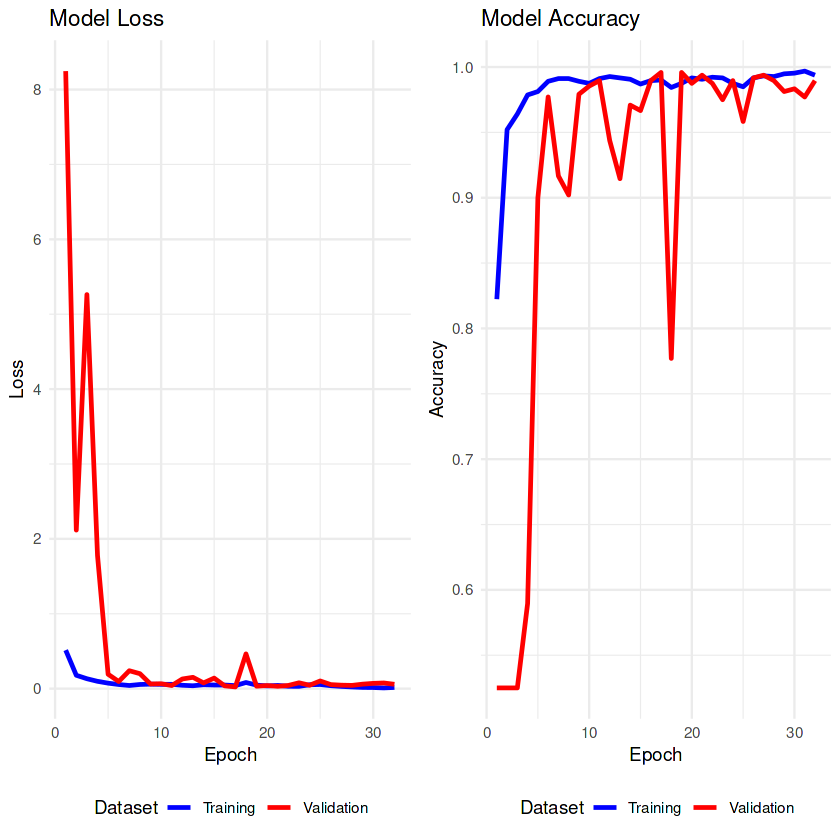

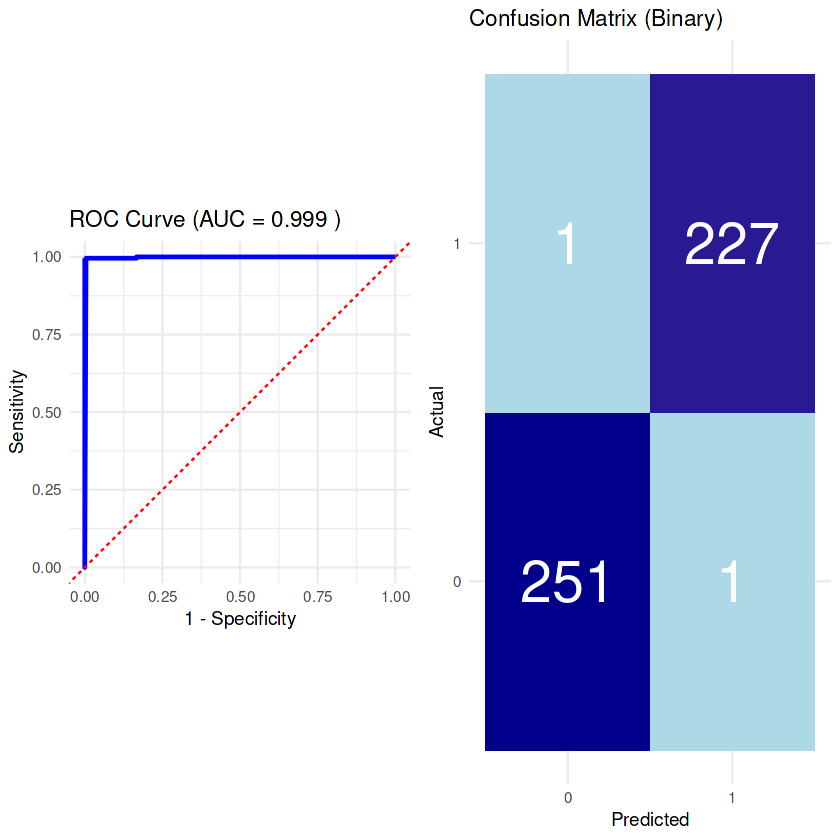


Detailed Statistics:
Positive pairs - Mean: 0.995 Std: 0.066 Range: 0.002 1 
Negative pairs - Mean: 0.011 Std: 0.07 Range: 0 0.956 
Probability separation: 0.985 
Enhanced training completed successfully!

=== FINAL SUMMARY ===
Model Type: Enhanced Siamese Network
Classes: Chickenpox, Cowpox, HFMD, Healthy, Measles, Monkeypox 
Total Parameters: 36166785 
Training completed with comprehensive evaluation!


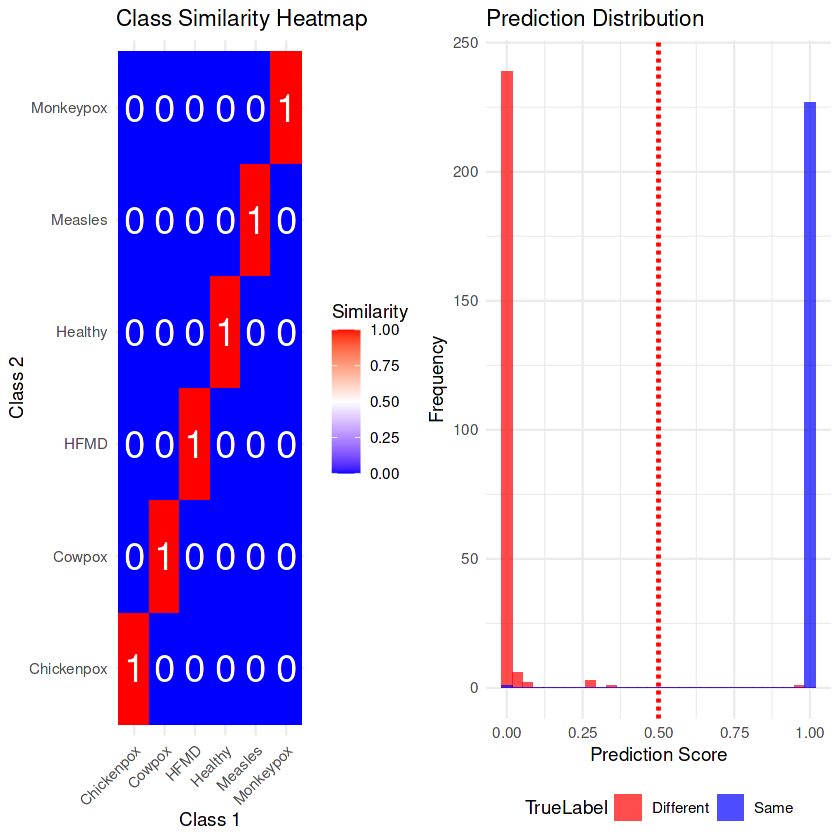

In [2]:
library(keras)
library(tensorflow)
library(caret)
library(magrittr)
library(abind)
library(ggplot2)
library(dplyr)
library(gridExtra)
library(pROC)
library(corrplot)
library(reshape2)

# Configuration - IMPROVED
CONFIG <- list(
  base_dir = "/kaggle/input/mpox-skin-lesion-dataset-version-20-msld-v20/Augmented Images/Augmented Images/FOLDS_AUG/fold1_AUG/Train",
  classes = c("Chickenpox", "Cowpox", "HFMD", "Healthy", "Measles", "Monkeypox"),
  img_size = c(128, 128),
  batch_size = 32,
  max_pairs_per_class = 200,
  learning_rate = 0.001,
  epochs = 50,
  max_per_class = 200
)

# Load sample of images - IMPROVED to use more data
load_sample_images <- function(base_dir, classes, target_size, max_per_class = 200) {
  images <- list()
  labels <- c()
  
  for (i in seq_along(classes)) {
    class_dir <- file.path(base_dir, classes[i])
    
    if (!dir.exists(class_dir)) {
      cat("Warning: Directory", class_dir, "does not exist\n")
      next
    }
    
    img_files <- list.files(class_dir, pattern = "\\.(jpg|jpeg|png)$", 
                           full.names = TRUE, ignore.case = TRUE)
    
    cat("Found", length(img_files), "images in", classes[i], "\n")
    
    if (length(img_files) > max_per_class) {
      img_files <- sample(img_files, max_per_class)
    }
    
    cat("Loading", length(img_files), "images from", classes[i], "\n")
    
    for (img_file in img_files) {
      tryCatch({
        img <- image_load(img_file, target_size = target_size) %>%
          image_to_array() %>%
          `/`(255)
        
        if (length(dim(img)) == 2) {
          img <- array(img, dim = c(dim(img), 1))
        }
        
        if (dim(img)[3] == 1) {
          img <- array(rep(img, 3), dim = c(dim(img)[1:2], 3))
        }
        
        images <- append(images, list(img))
        labels <- c(labels, i)
      }, error = function(e) {
        cat("Error loading", img_file, ":", e$message, "\n")
      })
    }
  }
  
  if (length(images) == 0) {
    stop("No images were loaded successfully")
  }
  
  first_img_dims <- dim(images[[1]])
  n_images <- length(images)
  image_array <- array(0, dim = c(n_images, first_img_dims[1], first_img_dims[2], first_img_dims[3]))
  
  for (i in seq_len(n_images)) {
    image_array[i, , , ] <- images[[i]]
  }
  
  cat("Final image array dimensions:", dim(image_array), "\n")
  cat("Class distribution:", table(labels), "\n")
  
  return(list(images = image_array, labels = labels))
}

# IMPROVED: Better pair creation strategy with class tracking
create_smart_pairs <- function(images, labels, max_pairs_per_class = 200) {
  n_classes <- length(unique(labels))
  class_indices <- split(seq_along(labels), labels)
  
  pairs_left <- list()
  pairs_right <- list()
  pair_labels <- c()
  pair_classes <- list()  # Track which classes are in each pair
  
  img_dims <- dim(images)
  cat("Images array dimensions:", img_dims, "\n")
  
  if (length(img_dims) != 4) {
    stop("Expected 4D image array (batch, height, width, channels), got ", length(img_dims), "D")
  }
  
  # Create positive pairs (same class)
  positive_pairs <- 0
  for (class_idx in seq_len(n_classes)) {
    indices <- class_indices[[class_idx]]
    
    if (length(indices) < 2) {
      cat("Skipping class", class_idx, "- not enough samples\n")
      next
    }
    
    indices <- sample(indices)
    pairs_created <- 0
    
    for (i in seq_len(length(indices) - 1)) {
      if (pairs_created >= max_pairs_per_class) break
      
      for (j in (i + 1):length(indices)) {
        if (pairs_created >= max_pairs_per_class) break
        
        img1 <- images[indices[i], , , , drop = FALSE]
        img2 <- images[indices[j], , , , drop = FALSE]
        
        pairs_left <- append(pairs_left, list(img1))
        pairs_right <- append(pairs_right, list(img2))
        pair_labels <- c(pair_labels, 1)
        pair_classes <- append(pair_classes, list(c(class_idx, class_idx)))
        
        pairs_created <- pairs_created + 1
        positive_pairs <- positive_pairs + 1
      }
    }
    
    cat("Created", pairs_created, "positive pairs for class", class_idx, "\n")
  }
  
  # Create equal number of negative pairs (different classes)
  negative_pairs <- 0
  target_negative_pairs <- positive_pairs
  
  cat("Creating", target_negative_pairs, "negative pairs...\n")
  
  attempts <- 0
  max_attempts <- target_negative_pairs * 3
  
  while (negative_pairs < target_negative_pairs && attempts < max_attempts) {
    attempts <- attempts + 1
    
    classes_to_sample <- sample(seq_len(n_classes), 2)
    class1 <- classes_to_sample[1]
    class2 <- classes_to_sample[2]
    
    indices1 <- class_indices[[class1]]
    indices2 <- class_indices[[class2]]
    
    if (length(indices1) > 0 && length(indices2) > 0) {
      idx1 <- sample(indices1, 1)
      idx2 <- sample(indices2, 1)
      
      img1 <- images[idx1, , , , drop = FALSE]
      img2 <- images[idx2, , , , drop = FALSE]
      
      pairs_left <- append(pairs_left, list(img1))
      pairs_right <- append(pairs_right, list(img2))
      pair_labels <- c(pair_labels, 0)
      pair_classes <- append(pair_classes, list(c(class1, class2)))
      
      negative_pairs <- negative_pairs + 1
    }
  }
  
  cat("Created", positive_pairs, "positive pairs and", negative_pairs, "negative pairs\n")
  
  # Convert to arrays
  n_pairs <- length(pairs_left)
  if (n_pairs == 0) {
    stop("No pairs were created")
  }
  
  pair_dims <- dim(pairs_left[[1]])
  
  left_array <- array(0, dim = c(n_pairs, pair_dims[2], pair_dims[3], pair_dims[4]))
  right_array <- array(0, dim = c(n_pairs, pair_dims[2], pair_dims[3], pair_dims[4]))
  
  for (i in seq_len(n_pairs)) {
    left_array[i, , , ] <- pairs_left[[i]][1, , , ]
    right_array[i, , , ] <- pairs_right[[i]][1, , , ]
  }
  
  cat("Final arrays - Left:", dim(left_array), "Right:", dim(right_array), "\n")
  
  return(list(
    left = left_array,
    right = right_array,
    labels = pair_labels,
    classes = pair_classes
  ))
}

# IMPROVED: Lighter but more effective base network
create_base_network <- function(input_shape) {
  input <- layer_input(shape = input_shape)
  
  x <- input %>%
    # Block 1
    layer_conv_2d(64, c(3, 3), activation = "relu", padding = "same") %>%
    layer_batch_normalization() %>%
    layer_max_pooling_2d(c(2, 2)) %>%
    layer_dropout(0.25) %>%
    
    # Block 2
    layer_conv_2d(128, c(3, 3), activation = "relu", padding = "same") %>%
    layer_batch_normalization() %>%
    layer_max_pooling_2d(c(2, 2)) %>%
    layer_dropout(0.25) %>%
    
    # Block 3
    layer_conv_2d(256, c(3, 3), activation = "relu", padding = "same") %>%
    layer_batch_normalization() %>%
    layer_max_pooling_2d(c(2, 2)) %>%
    layer_dropout(0.25) %>%
    
    # Block 4
    layer_conv_2d(512, c(3, 3), activation = "relu", padding = "same") %>%
    layer_batch_normalization() %>%
    layer_max_pooling_2d(c(2, 2)) %>%
    layer_dropout(0.25) %>%
    
    # Dense layers
    layer_flatten() %>%
    layer_dense(1024, activation = "relu") %>%
    layer_batch_normalization() %>%
    layer_dropout(0.5) %>%
    layer_dense(512, activation = "relu") %>%
    layer_batch_normalization() %>%
    layer_dropout(0.5) %>%
    layer_dense(256, activation = NULL)  # Embedding layer
  
  return(keras_model(input, x))
}

# Function to create comprehensive evaluation plots
create_evaluation_plots <- function(history, val_predictions, val_labels, val_classes, class_names) {
  
  # 1. Training History Plot
  history_df <- data.frame(
    epoch = 1:length(history$metrics$loss),
    train_loss = history$metrics$loss,
    val_loss = history$metrics$val_loss,
    train_acc = history$metrics$accuracy,
    val_acc = history$metrics$val_accuracy
  )
  
  # Loss plot
  loss_plot <- ggplot(history_df, aes(x = epoch)) +
    geom_line(aes(y = train_loss, color = "Training"), size = 1) +
    geom_line(aes(y = val_loss, color = "Validation"), size = 1) +
    scale_color_manual(values = c("Training" = "blue", "Validation" = "red")) +
    labs(title = "Model Loss", x = "Epoch", y = "Loss", color = "Dataset") +
    theme_minimal() +
    theme(legend.position = "bottom")
  
  # Accuracy plot
  acc_plot <- ggplot(history_df, aes(x = epoch)) +
    geom_line(aes(y = train_acc, color = "Training"), size = 1) +
    geom_line(aes(y = val_acc, color = "Validation"), size = 1) +
    scale_color_manual(values = c("Training" = "blue", "Validation" = "red")) +
    labs(title = "Model Accuracy", x = "Epoch", y = "Accuracy", color = "Dataset") +
    theme_minimal() +
    theme(legend.position = "bottom")
  
  # 2. ROC Curve
  roc_obj <- roc(val_labels, as.numeric(val_predictions))
  roc_data <- data.frame(
    sensitivity = roc_obj$sensitivities,
    specificity = roc_obj$specificities
  )
  
  roc_plot <- ggplot(roc_data, aes(x = 1 - specificity, y = sensitivity)) +
    geom_line(color = "blue", size = 1) +
    geom_abline(slope = 1, intercept = 0, linetype = "dashed", color = "red") +
    labs(title = paste("ROC Curve (AUC =", round(auc(roc_obj), 3), ")"),
         x = "1 - Specificity", y = "Sensitivity") +
    theme_minimal() +
    coord_equal()
  
  # 3. Confusion Matrix for binary classification
  binary_predictions <- ifelse(val_predictions > 0.5, 1, 0)
  cm_binary <- confusionMatrix(factor(binary_predictions), factor(val_labels))
  
  cm_data <- as.data.frame(cm_binary$table)
  colnames(cm_data) <- c("Predicted", "Actual", "Freq")
  
  cm_plot <- ggplot(cm_data, aes(x = Predicted, y = Actual, fill = Freq)) +
    geom_tile() +
    geom_text(aes(label = Freq), color = "white", size = 12) +
    scale_fill_gradient(low = "lightblue", high = "darkblue") +
    labs(title = "Confusion Matrix (Binary)", x = "Predicted", y = "Actual") +
    theme_minimal() +
    theme(legend.position = "none")
  
  # 4. Class-wise similarity heatmap
  # Create similarity matrix between classes
  n_classes <- length(class_names)
  similarity_matrix <- matrix(0, nrow = n_classes, ncol = n_classes)
  
  # Calculate average similarity for each class pair
  for (i in 1:length(val_classes)) {
    class1 <- val_classes[[i]][1]
    class2 <- val_classes[[i]][2]
    similarity <- val_predictions[i]
    
    # For positive pairs (same class)
    if (val_labels[i] == 1) {
      similarity_matrix[class1, class2] <- similarity_matrix[class1, class2] + similarity
      similarity_matrix[class2, class1] <- similarity_matrix[class2, class1] + similarity
    }
  }
  
  # Normalize by number of pairs
  pair_counts <- matrix(0, nrow = n_classes, ncol = n_classes)
  for (i in 1:length(val_classes)) {
    class1 <- val_classes[[i]][1]
    class2 <- val_classes[[i]][2]
    
    if (val_labels[i] == 1) {
      pair_counts[class1, class2] <- pair_counts[class1, class2] + 1
      pair_counts[class2, class1] <- pair_counts[class2, class1] + 1
    }
  }
  
  # Avoid division by zero
  pair_counts[pair_counts == 0] <- 1
  similarity_matrix <- similarity_matrix / pair_counts
  
  # Set diagonal to 1 (same class similarity)
  diag(similarity_matrix) <- 1
  
  rownames(similarity_matrix) <- class_names
  colnames(similarity_matrix) <- class_names
  
  # Convert to long format for ggplot
  similarity_long <- melt(similarity_matrix)
  colnames(similarity_long) <- c("Class1", "Class2", "Similarity")
  
  heatmap_plot <- ggplot(similarity_long, aes(x = Class1, y = Class2, fill = Similarity)) +
    geom_tile() +
    geom_text(aes(label = round(Similarity, 2)), color = "white", size = 8) +
    scale_fill_gradient2(low = "blue", mid = "white", high = "red", midpoint = 0.5) +
    labs(title = "Class Similarity Heatmap", x = "Class 1", y = "Class 2") +
    theme_minimal() +
    theme(axis.text.x = element_text(angle = 45, hjust = 1))
  
  # 5. Prediction distribution
  pred_data <- data.frame(
    Predictions = val_predictions,
    TrueLabel = factor(val_labels, labels = c("Different", "Same"))
  )
  
  dist_plot <- ggplot(pred_data, aes(x = Predictions, fill = TrueLabel)) +
    geom_histogram(alpha = 0.7, bins = 30, position = "identity") +
    geom_vline(xintercept = 0.5, linetype = "dashed", color = "red", size = 1) +
    scale_fill_manual(values = c("Different" = "red", "Same" = "blue")) +
    labs(title = "Prediction Distribution", x = "Prediction Score", y = "Frequency") +
    theme_minimal() +
    theme(legend.position = "bottom")
  
  return(list(
    loss_plot = loss_plot,
    acc_plot = acc_plot,
    roc_plot = roc_plot,
    cm_plot = cm_plot,
    heatmap_plot = heatmap_plot,
    dist_plot = dist_plot
  ))
}

# Function to calculate comprehensive metrics
calculate_metrics <- function(val_predictions, val_labels, threshold = 0.5) {
  # Binary predictions
  binary_predictions <- ifelse(val_predictions > threshold, 1, 0)
  
  # Confusion matrix
  cm <- confusionMatrix(factor(binary_predictions), factor(val_labels))
  
  # ROC curve
  roc_obj <- roc(val_labels, as.numeric(val_predictions))
  
  # Calculate metrics
  metrics <- list(
    accuracy = cm$overall['Accuracy'],
    sensitivity = cm$byClass['Sensitivity'],
    specificity = cm$byClass['Specificity'],
    precision = cm$byClass['Pos Pred Value'],
    recall = cm$byClass['Sensitivity'],
    f1_score = cm$byClass['F1'],
    auc = auc(roc_obj),
    confusion_matrix = cm$table
  )
  
  return(metrics)
}

# Main training function with comprehensive evaluation
train_siamese_network <- function() {
  cat("Starting Enhanced Siamese Network Training\n")
  cat("==========================================\n")
  
  # Load data
  cat("Loading images...\n")
  data <- load_sample_images(CONFIG$base_dir, CONFIG$classes, CONFIG$img_size, CONFIG$max_per_class)
  cat("Loaded", dim(data$images)[1], "images total\n")
  
  # Create pairs
  cat("Creating pairs...\n")
  pairs <- create_smart_pairs(data$images, data$labels, CONFIG$max_pairs_per_class)
  cat("Created", length(pairs$labels), "total pairs\n")
  
  # Shuffle pairs
  set.seed(42)
  n_pairs <- length(pairs$labels)
  shuffle_idx <- sample(n_pairs)
  pairs_left <- pairs$left[shuffle_idx, , , , drop = FALSE]
  pairs_right <- pairs$right[shuffle_idx, , , , drop = FALSE]
  pairs_labels <- pairs$labels[shuffle_idx]
  pairs_classes <- pairs$classes[shuffle_idx]
  
  # Split data
  train_idx <- seq_len(floor(0.8 * n_pairs))
  val_idx <- (length(train_idx) + 1):n_pairs
  
  train_left <- pairs_left[train_idx, , , , drop = FALSE]
  train_right <- pairs_right[train_idx, , , , drop = FALSE]
  train_labels <- pairs_labels[train_idx]
  
  val_left <- pairs_left[val_idx, , , , drop = FALSE]
  val_right <- pairs_right[val_idx, , , , drop = FALSE]
  val_labels <- pairs_labels[val_idx]
  val_classes <- pairs_classes[val_idx]
  
  cat("Training pairs:", length(train_labels), "(positive:", sum(train_labels), "negative:", sum(train_labels == 0), ")\n")
  cat("Validation pairs:", length(val_labels), "(positive:", sum(val_labels), "negative:", sum(val_labels == 0), ")\n")
  
  # Build model
  cat("Building model...\n")
  input_shape <- c(CONFIG$img_size, 3)
  base_network <- create_base_network(input_shape)
  
  # Input layers
  input_a <- layer_input(shape = input_shape, name = "input_a")
  input_b <- layer_input(shape = input_shape, name = "input_b")
  
  # Process inputs through base network
  processed_a <- base_network(input_a)
  processed_b <- base_network(input_b)
  
  # Combine features
  combined <- layer_concatenate(list(processed_a, processed_b))
  
  # Similarity layers
  similarity <- combined %>%
    layer_dense(512, activation = "relu") %>%
    layer_dropout(0.5) %>%
    layer_dense(256, activation = "relu") %>%
    layer_dropout(0.5) %>%
    layer_dense(1, activation = "sigmoid")
  
  # Create model
  model <- keras_model(list(input_a, input_b), similarity)
  
  # Compile model
  model %>% compile(
    optimizer = optimizer_adam(learning_rate = CONFIG$learning_rate),
    loss = "binary_crossentropy",
    metrics = list("accuracy")
  )
  
  # Print model summary
  cat("Model summary:\n")
  summary(model)
  
  # Callbacks
  callbacks <- list(
    callback_early_stopping(
      monitor = "val_loss",
      patience = 15, 
      restore_best_weights = TRUE, 
      verbose = 1
    ),
    callback_reduce_lr_on_plateau(
      monitor = "val_loss",
      patience = 8, 
      factor = 0.5, 
      verbose = 1, 
      min_lr = 1e-7
    )
  )
  
  # Train model
  cat("Starting training...\n")
  history <- model %>% fit(
    x = list(train_left, train_right),
    y = train_labels,
    validation_data = list(list(val_left, val_right), val_labels),
    batch_size = CONFIG$batch_size,
    epochs = CONFIG$epochs,
    callbacks = callbacks,
    verbose = 1
  )
  
  # Evaluate model
  cat("Evaluating model...\n")
  val_predictions <- predict(model, list(val_left, val_right), verbose = 0)
  
  # Calculate comprehensive metrics
  metrics <- calculate_metrics(val_predictions, val_labels)
  
  # Print detailed results
  cat("\n=== COMPREHENSIVE EVALUATION RESULTS ===\n")
  cat("Accuracy:", round(metrics$accuracy * 100, 2), "%\n")
  cat("Precision:", round(metrics$precision * 100, 2), "%\n")
  cat("Recall (Sensitivity):", round(metrics$recall * 100, 2), "%\n")
  cat("Specificity:", round(metrics$specificity * 100, 2), "%\n")
  cat("F1 Score:", round(metrics$f1_score * 100, 2), "%\n")
  cat("AUC:", round(metrics$auc, 3), "\n")
  cat("\nConfusion Matrix:\n")
  print(metrics$confusion_matrix)
  
  # Create evaluation plots
  cat("\nGenerating evaluation plots...\n")
  plots <- create_evaluation_plots(history, val_predictions, val_labels, val_classes, CONFIG$classes)
  
  # Display plots
  cat("Displaying plots...\n")
  
  # Arrange plots in a grid
  grid.arrange(plots$loss_plot, plots$acc_plot, ncol = 2)
  grid.arrange(plots$roc_plot, plots$cm_plot, ncol = 2)
  grid.arrange(plots$heatmap_plot, plots$dist_plot, ncol = 2)
  
  # Create feature extractor
  feature_extractor <- keras_model(inputs = base_network$input, 
                                  outputs = base_network$output)
  
  # Additional statistics
  pos_probs <- val_predictions[val_labels == 1]
  neg_probs <- val_predictions[val_labels == 0]
  
  cat("\nDetailed Statistics:\n")
  cat("Positive pairs - Mean:", round(mean(pos_probs), 3), 
      "Std:", round(sd(pos_probs), 3), 
      "Range:", round(range(pos_probs), 3), "\n")
  cat("Negative pairs - Mean:", round(mean(neg_probs), 3), 
      "Std:", round(sd(neg_probs), 3), 
      "Range:", round(range(neg_probs), 3), "\n")
  
  separation <- abs(mean(pos_probs) - mean(neg_probs))
  cat("Probability separation:", round(separation, 3), "\n")
  
  return(list(
    model = model,
    feature_extractor = feature_extractor,
    history = history,
    base_network = base_network,
    metrics = metrics,
    plots = plots,
    predictions = val_predictions,
    val_labels = val_labels,
    threshold = 0.5
  ))
}

# Check directory and run training
cat("Enhanced Configuration:\n")
str(CONFIG)
cat("\n")

if (!dir.exists(CONFIG$base_dir)) {
  cat("Error: Base directory does not exist:", CONFIG$base_dir, "\n")
  cat("Please update CONFIG$base_dir with the correct path\n")
} else {
  cat("Directory exists. Starting enhanced training...\n")
  results <- train_siamese_network()
  cat("Enhanced training completed successfully!\n")
  
  # Save results summary
  cat("\n=== FINAL SUMMARY ===\n")
  cat("Model Type: Enhanced Siamese Network\n")
  cat("Classes:", paste(CONFIG$classes, collapse = ", "), "\n")
  cat("Total Parameters:", sum(results$model$count_params()), "\n")
  cat("Training completed with comprehensive evaluation!\n")
}